In [1]:
# Cell 1 — Imports and project-location detection

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Find the project root from the notebook's current working directory.
cwd = Path.cwd().resolve()

candidates = [cwd] + list(cwd.parents)
PROJECT_DIR = None

for candidate in candidates:
    if (
        (candidate / "results").is_dir()
        and (candidate / "results_cnn_baseline").is_dir()
        and (candidate / "checkpoints").is_dir()
        and (candidate / "checkpoints_cnn_baseline").is_dir()
    ):
        PROJECT_DIR = candidate
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Could not locate NNDL_Deepfake_Project. "
        "Open this notebook inside the project's ipynbs folder."
    )

EN_RESULTS = PROJECT_DIR / "results"
CNN_RESULTS = PROJECT_DIR / "results_cnn_baseline"
EN_CHECKPOINTS = PROJECT_DIR / "checkpoints"
CNN_CHECKPOINTS = PROJECT_DIR / "checkpoints_cnn_baseline"

print("Project:", PROJECT_DIR)
print("EfficientNet results:", EN_RESULTS)
print("CNN results:", CNN_RESULTS)


Project: C:\Users\monil\Downloads\NNDL_Deepfake_Project
EfficientNet results: C:\Users\monil\Downloads\NNDL_Deepfake_Project\results
CNN results: C:\Users\monil\Downloads\NNDL_Deepfake_Project\results_cnn_baseline


In [2]:
# Cell 2 — Load the saved test metrics

def load_json(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

efficientnet_metrics = load_json(EN_RESULTS / "test_metrics.json")
cnn_metrics = load_json(CNN_RESULTS / "cnn_baseline_test_metrics.json")

print("EfficientNet-B0 test metrics:")
print(json.dumps(efficientnet_metrics, indent=2))

print("\nCustom CNN test metrics:")
print(json.dumps(cnn_metrics, indent=2))


EfficientNet-B0 test metrics:
{
  "loss": 0.08009508865326644,
  "accuracy": 0.969,
  "precision": 0.9662027833001988,
  "recall": 0.972,
  "f1": 0.9690927218344965,
  "roc_auc": 0.9962639999999999
}

Custom CNN test metrics:
{
  "loss": 0.5473132300376892,
  "accuracy": 0.723,
  "precision": 0.6987522281639929,
  "recall": 0.784,
  "f1": 0.7389255419415646,
  "roc_auc": 0.8018339999999999
}


In [3]:
# Cell 3 — Final CNN vs EfficientNet comparison table

metric_order = [
    ("accuracy", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-score"),
    ("roc_auc", "ROC-AUC"),
]

comparison = pd.DataFrame({
    "Metric": [label for key, label in metric_order],
    "Custom CNN": [float(cnn_metrics[key]) for key, _ in metric_order],
    "EfficientNet-B0": [float(efficientnet_metrics[key]) for key, _ in metric_order],
})

comparison["EfficientNet improvement"] = (
    comparison["EfficientNet-B0"] - comparison["Custom CNN"]
)

display(comparison.round(4))

comparison_dir = EN_RESULTS / "comparison"
comparison_dir.mkdir(parents=True, exist_ok=True)

comparison_csv = comparison_dir / "cnn_vs_efficientnet_comparison.csv"
comparison_json = comparison_dir / "cnn_vs_efficientnet_comparison.json"

comparison.to_csv(comparison_csv, index=False)
comparison.to_json(comparison_json, orient="records", indent=2)

print("\nSaved:")
print(comparison_csv)
print(comparison_json)


,Metric,Custom CNN,EfficientNet-B0,EfficientNet improvement
0,Accuracy,0.7230,0.9690,0.2460
1,Precision,0.6988,0.9662,0.2675
2,Recall,0.7840,0.9720,0.1880
3,F1-score,0.7389,0.9691,0.2302
4,ROC-AUC,0.8018,0.9963,0.1944



Saved:
C:\Users\monil\Downloads\NNDL_Deepfake_Project\results\comparison\cnn_vs_efficientnet_comparison.csv
C:\Users\monil\Downloads\NNDL_Deepfake_Project\results\comparison\cnn_vs_efficientnet_comparison.json


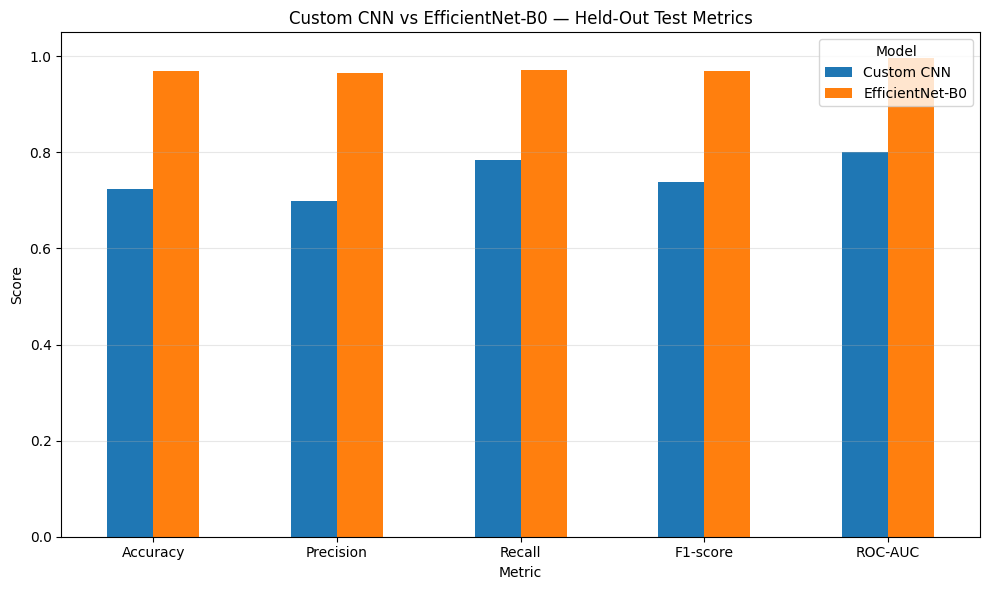

Saved: C:\Users\monil\Downloads\NNDL_Deepfake_Project\results\comparison\cnn_vs_efficientnet_metrics.png


In [4]:
# Cell 4 — Metric comparison chart

plot_df = comparison.set_index("Metric")[["Custom CNN", "EfficientNet-B0"]]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6),
    rot=0,
)

ax.set_title("Custom CNN vs EfficientNet-B0 — Held-Out Test Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Model")

plt.tight_layout()

metric_plot = comparison_dir / "cnn_vs_efficientnet_metrics.png"
plt.savefig(metric_plot, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", metric_plot)


In [5]:
# Cell 5 — Load both training histories

efficientnet_history = load_json(EN_RESULTS / "training_history.json")
cnn_history = load_json(CNN_RESULTS / "training_history.json")

print("EfficientNet epochs:", len(efficientnet_history["epoch"]))
print("CNN epochs:", len(cnn_history["epoch"]))

if "stage" in efficientnet_history:
    stages = list(efficientnet_history["stage"])
    print("EfficientNet stages:", stages)
    if "fine_tune" in stages:
        first_finetune_index = stages.index("fine_tune")
        print(
            "EfficientNet fine-tuning begins at epoch:",
            efficientnet_history["epoch"][first_finetune_index]
        )


EfficientNet epochs: 25
CNN epochs: 11
EfficientNet stages: ['head', 'head', 'head', 'head', 'head', 'head', 'head', 'head', 'head', 'head', 'fine_tune', 'fine_tune', 'fine_tune', 'fine_tune', 'fine_tune', 'fine_tune', 'fine_tune', 'fine_tune', 'fine_tune', 'fine_tune', 'fine_tune', 'fine_tune', 'fine_tune', 'fine_tune', 'fine_tune']
EfficientNet fine-tuning begins at epoch: 11


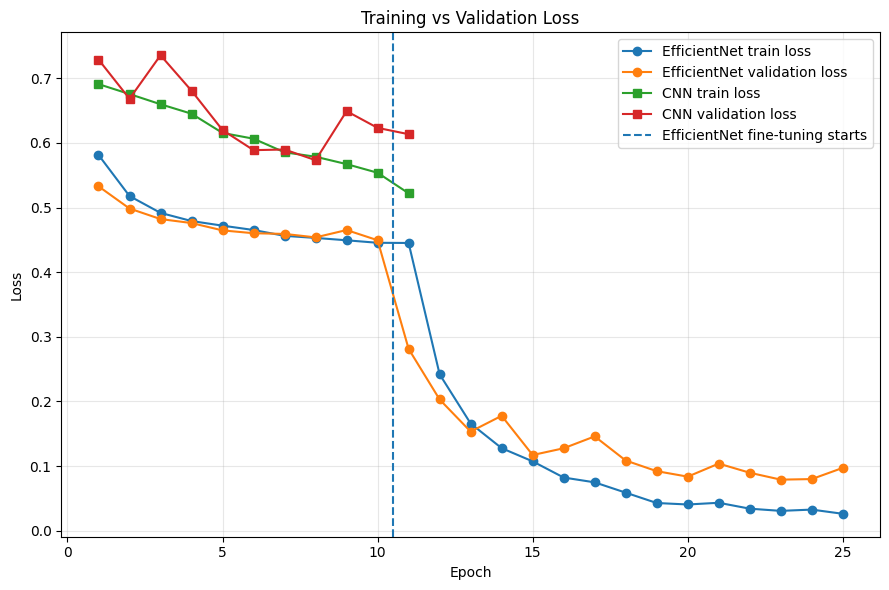

Saved: C:\Users\monil\Downloads\NNDL_Deepfake_Project\results\comparison\cnn_vs_efficientnet_loss_comparison.png


In [6]:
# Cell 6 — Training/validation loss comparison

plt.figure(figsize=(9, 6))

plt.plot(
    efficientnet_history["epoch"],
    efficientnet_history["train_loss"],
    marker="o",
    label="EfficientNet train loss",
)
plt.plot(
    efficientnet_history["epoch"],
    efficientnet_history["val_loss"],
    marker="o",
    label="EfficientNet validation loss",
)
plt.plot(
    cnn_history["epoch"],
    cnn_history["train_loss"],
    marker="s",
    label="CNN train loss",
)
plt.plot(
    cnn_history["epoch"],
    cnn_history["val_loss"],
    marker="s",
    label="CNN validation loss",
)

# Mark the EfficientNet Stage 1 -> Stage 2 boundary when present.
if "stage" in efficientnet_history and "fine_tune" in efficientnet_history["stage"]:
    idx = efficientnet_history["stage"].index("fine_tune")
    ft_epoch = efficientnet_history["epoch"][idx]
    plt.axvline(ft_epoch - 0.5, linestyle="--", label="EfficientNet fine-tuning starts")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_compare_path = comparison_dir / "cnn_vs_efficientnet_loss_comparison.png"
plt.savefig(loss_compare_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", loss_compare_path)


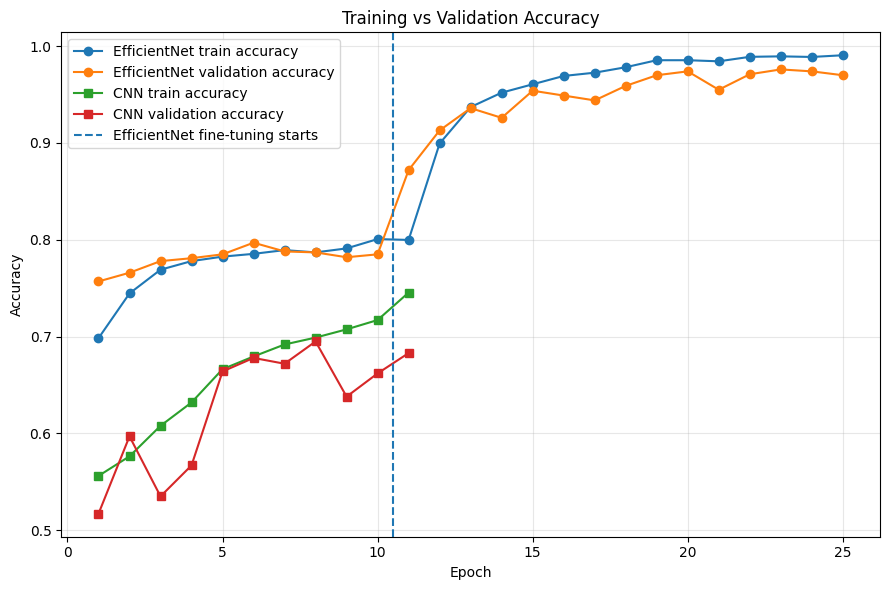

Saved: C:\Users\monil\Downloads\NNDL_Deepfake_Project\results\comparison\cnn_vs_efficientnet_accuracy_comparison.png


In [7]:
# Cell 7 — Training/validation accuracy comparison

plt.figure(figsize=(9, 6))

plt.plot(
    efficientnet_history["epoch"],
    efficientnet_history["train_accuracy"],
    marker="o",
    label="EfficientNet train accuracy",
)
plt.plot(
    efficientnet_history["epoch"],
    efficientnet_history["val_accuracy"],
    marker="o",
    label="EfficientNet validation accuracy",
)
plt.plot(
    cnn_history["epoch"],
    cnn_history["train_accuracy"],
    marker="s",
    label="CNN train accuracy",
)
plt.plot(
    cnn_history["epoch"],
    cnn_history["val_accuracy"],
    marker="s",
    label="CNN validation accuracy",
)

if "stage" in efficientnet_history and "fine_tune" in efficientnet_history["stage"]:
    idx = efficientnet_history["stage"].index("fine_tune")
    ft_epoch = efficientnet_history["epoch"][idx]
    plt.axvline(ft_epoch - 0.5, linestyle="--", label="EfficientNet fine-tuning starts")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

accuracy_compare_path = comparison_dir / "cnn_vs_efficientnet_accuracy_comparison.png"
plt.savefig(accuracy_compare_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", accuracy_compare_path)


In [8]:
# Cell 8 — Verify saved model files and final test-score metadata

expected_files = {
    "EfficientNet final": EN_CHECKPOINTS / "efficientnet_b0_final.pth",
    "EfficientNet best": EN_CHECKPOINTS / "efficientnet_b0_best.pth",
    "CNN final": CNN_CHECKPOINTS / "cnn_baseline_final.pth",
    "CNN best": CNN_CHECKPOINTS / "cnn_baseline_best.pth",
}

for name, path in expected_files.items():
    print(f"{name}: {'FOUND' if path.exists() else 'MISSING'}")
    if path.exists():
        print(f"  {path}")

missing = [str(p) for p in expected_files.values() if not p.exists()]
if missing:
    raise FileNotFoundError("One or more expected checkpoints are missing.")

# The final checkpoints contain the exact test scores recorded when the
# held-out test set was evaluated in Colab. Compare them with the JSON files.
import torch

checkpoint_specs = [
    ("EfficientNet-B0", EN_CHECKPOINTS / "efficientnet_b0_final.pth", efficientnet_metrics),
    ("Custom CNN", CNN_CHECKPOINTS / "cnn_baseline_final.pth", cnn_metrics),
]

for name, path, json_metrics in checkpoint_specs:
    ckpt = torch.load(path, map_location="cpu", weights_only=False)

    print(f"\n{name} checkpoint metadata:")
    print("  architecture:", ckpt.get("architecture"))
    print("  target convention:", ckpt.get("target_convention"))
    print("  best checkpoint epoch:", ckpt.get("best_checkpoint_epoch"))
    print("  best checkpoint stage:", ckpt.get("best_checkpoint_stage"))

    assert ckpt.get("target_convention") == "FAKE=1, REAL=0", (
        f"{name}: unexpected target convention"
    )

    stored_metrics = ckpt.get("test_metrics")
    assert stored_metrics is not None, f"{name}: test_metrics missing from checkpoint"

    for key in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        json_value = float(json_metrics[key])
        stored_value = float(stored_metrics[key])
        assert np.isclose(json_value, stored_value, atol=1e-7), (
            f"{name}: {key} differs between JSON and final checkpoint "
            f"({json_value} vs {stored_value})"
        )

    print("  ✓ Checkpoint test scores match the saved test_metrics JSON.")


EfficientNet final: FOUND
  C:\Users\monil\Downloads\NNDL_Deepfake_Project\checkpoints\efficientnet_b0_final.pth
EfficientNet best: FOUND
  C:\Users\monil\Downloads\NNDL_Deepfake_Project\checkpoints\efficientnet_b0_best.pth
CNN final: FOUND
  C:\Users\monil\Downloads\NNDL_Deepfake_Project\checkpoints_cnn_baseline\cnn_baseline_final.pth
CNN best: FOUND
  C:\Users\monil\Downloads\NNDL_Deepfake_Project\checkpoints_cnn_baseline\cnn_baseline_best.pth

EfficientNet-B0 checkpoint metadata:
  architecture: efficientnet_b0
  target convention: FAKE=1, REAL=0
  best checkpoint epoch: 23
  best checkpoint stage: fine_tune_best_overall
  ✓ Checkpoint test scores match the saved test_metrics JSON.

Custom CNN checkpoint metadata:
  architecture: DeepfakeCNN_custom_baseline
  target convention: FAKE=1, REAL=0
  best checkpoint epoch: 8
  best checkpoint stage: None
  ✓ Checkpoint test scores match the saved test_metrics JSON.


In [9]:
# Final result summary

# Compare all five reported test metrics, not only accuracy and F1.
better_by_metric = {}
for key, label in metric_order:
    cnn_value = float(cnn_metrics[key])
    en_value = float(efficientnet_metrics[key])
    if en_value > cnn_value:
        better_by_metric[label] = "EfficientNet-B0"
    elif en_value < cnn_value:
        better_by_metric[label] = "Custom CNN"
    else:
        better_by_metric[label] = "Tie"

print("FINAL EXPERIMENT SUMMARY")
print("=" * 70)
print(comparison.round(4).to_string(index=False))
print("\nBetter model by metric:")
for metric, model_name in better_by_metric.items():
    print(f"  {metric:10s}: {model_name}")

acc_cnn = float(cnn_metrics["accuracy"])
acc_en = float(efficientnet_metrics["accuracy"])
f1_cnn = float(cnn_metrics["f1"])
f1_en = float(efficientnet_metrics["f1"])

if acc_en > acc_cnn and f1_en > f1_cnn:
    conclusion = (
        "EfficientNet-B0 is better than the custom CNN on both test accuracy "
        "and F1-score. The remaining metrics should still be reported individually."
    )
elif acc_en < acc_cnn and f1_en < f1_cnn:
    conclusion = (
        "The custom CNN is better than EfficientNet-B0 on both test accuracy "
        "and F1-score. The result should be reported as a trade-off rather "
        "than claiming transfer learning improved performance."
    )
else:
    conclusion = (
        "The models trade wins across the main test metrics. The final report "
        "should discuss the metric-by-metric trade-off rather than relying on accuracy alone."
    )

print("\nConclusion:")
print(conclusion)

summary_path = comparison_dir / "final_model_comparison_summary.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("FINAL EXPERIMENT SUMMARY\n")
    f.write("=" * 70 + "\n")
    f.write(comparison.round(6).to_string(index=False))
    f.write("\n\nBetter model by metric:\n")
    for metric, model_name in better_by_metric.items():
        f.write(f"{metric}: {model_name}\n")
    f.write("\n" + conclusion + "\n")

print("\nSaved:", summary_path)


FINAL EXPERIMENT SUMMARY
   Metric  Custom CNN  EfficientNet-B0  EfficientNet improvement
 Accuracy      0.7230           0.9690                    0.2460
Precision      0.6988           0.9662                    0.2675
   Recall      0.7840           0.9720                    0.1880
 F1-score      0.7389           0.9691                    0.2302
  ROC-AUC      0.8018           0.9963                    0.1944

Better model by metric:
  Accuracy  : EfficientNet-B0
  Precision : EfficientNet-B0
  Recall    : EfficientNet-B0
  F1-score  : EfficientNet-B0
  ROC-AUC   : EfficientNet-B0

Conclusion:
EfficientNet-B0 is better than the custom CNN on both test accuracy and F1-score. The remaining metrics should still be reported individually.

Saved: C:\Users\monil\Downloads\NNDL_Deepfake_Project\results\comparison\final_model_comparison_summary.txt


## Held-out test visualizations

The following figures were generated during the final held-out test evaluation in Colab. This notebook only displays the saved figures; it does not re-run evaluation on the test images.


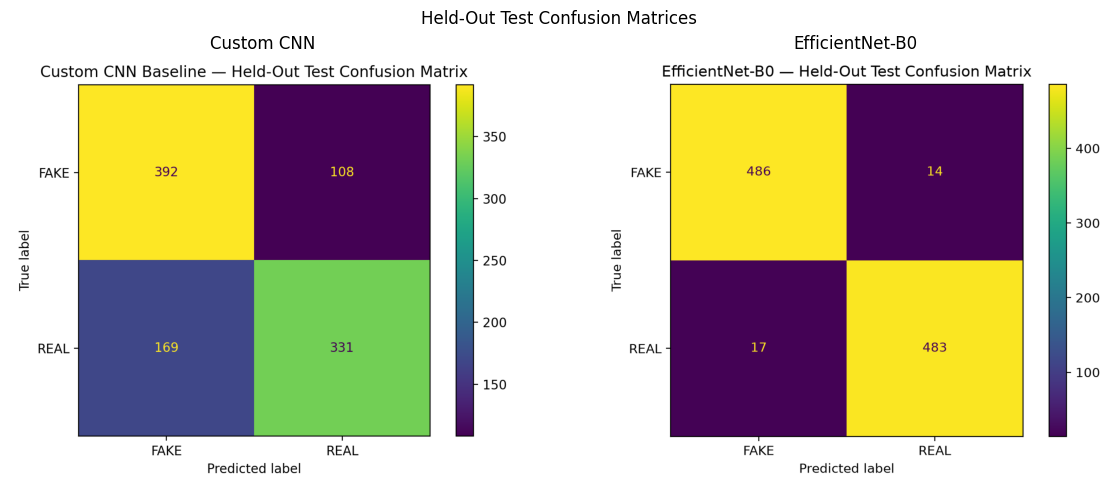

Saved: C:\Users\monil\Downloads\NNDL_Deepfake_Project\results\comparison\cnn_vs_efficientnet_confusion_matrices.png


In [10]:
# Cell 9 — Display held-out test confusion matrices side by side

from PIL import Image

cm_paths = [
    ("Custom CNN", CNN_RESULTS / "cnn_baseline_confusion_matrix.png"),
    ("EfficientNet-B0", EN_RESULTS / "confusion_matrix.png"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, path) in zip(axes, cm_paths):
    if not path.exists():
        raise FileNotFoundError(f"Missing saved confusion matrix: {path}")
    ax.imshow(Image.open(path))
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("Held-Out Test Confusion Matrices")
plt.tight_layout()

path = comparison_dir / "cnn_vs_efficientnet_confusion_matrices.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)


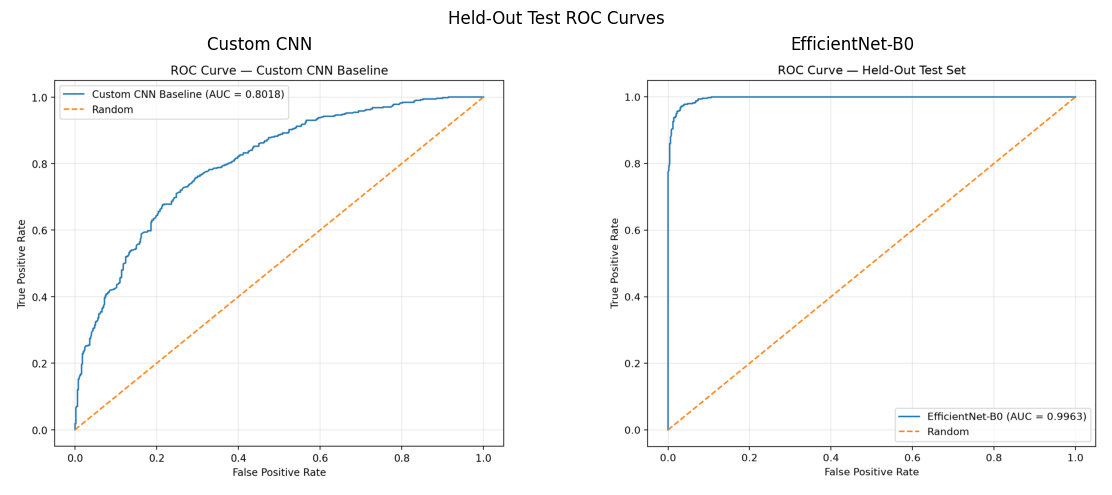

Saved: C:\Users\monil\Downloads\NNDL_Deepfake_Project\results\comparison\cnn_vs_efficientnet_roc_curves.png


In [11]:
# Cell 10 — Display held-out test ROC curves side by side

roc_paths = [
    ("Custom CNN", CNN_RESULTS / "cnn_baseline_roc_curve.png"),
    ("EfficientNet-B0", EN_RESULTS / "roc_curve.png"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, path) in zip(axes, roc_paths):
    if not path.exists():
        raise FileNotFoundError(f"Missing saved ROC curve: {path}")
    ax.imshow(Image.open(path))
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("Held-Out Test ROC Curves")
plt.tight_layout()

path = comparison_dir / "cnn_vs_efficientnet_roc_curves.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", path)
